# Laboratorio 2: Agrupacion

Este es el diccionario proporcionado por Senecafé sobre los datos que debemos analizar para cumplir con la tarea propuesta.

| ATRIBUTO | DEFINICIÓN |
| :- | :- |
| **ID** | Código único generado para cada grano de café inspeccionado.  |
| **Área** | Superficie ocupada por el grano, medida como el número total de píxeles dentro de sus límites. Indica el tamaño del grano. |
| **Perímetro** | Longitud de la frontera del grano, equivalente a su circunferencia. Refleja la complejidad y continuidad del borde. |
| **LongitudEjeMayor** | Distancia entre los extremos de la línea más larga que puede trazarse a lo largo del grano. Representa la longitud máxima del grano. |
| **LongitudEjeMenor** | Longitud de la línea más larga que puede trazarse perpendicular al eje mayor. Refleja el ancho máximo transversal del grano. |
| **RelaciónAspecto** | Relación entre la longitud del eje mayor y la del eje menor. Indica si el grano es Alargado (> 1.3) o Redondeado (≤ 1.3).  |
| **Excentricidad** | Medida de la desviación de la forma respecto a un círculo, basada en la elipse equivalente. Valores cercanos a 0 indican formas circulares; cercanos a 1, formas alargadas. |
| **ÁreaConvexa** | Número de píxeles contenidos en el polígono convexo más pequeño que abarca el grano. Permite identificar irregularidades en el borde. |
| **DiámetroEquivalente** | Diámetro de un círculo con el mismo área que el grano. Facilita la comparación entre granos de distintas formas mediante una medida circular equivalente. |
| **Medida** | Proporción entre el área del grano y el área de su caja delimitadora (bounding box). Evalúa qué tan bien el grano ocupa su espacio mínimo rectangular. |
| **Solidez** | Proporción entre el área del grano y el área de su envolvente convexa. Indica la regularidad de la forma. |
| **Redondez** | Medida calculada con la fórmula (4πA) / P^2. Indica circularidad. Valores cercanos a 1 indican formas circulares; valores bajos, irregularidad o elongación. |
| **Compacidad** | Índice alternativo de redondez: relación entre el diámetro y el eje mayor. Valores altos reflejan granos más compactos y redondeados. |
| **FactorForma1** | Medida geométrica derivada que combina variables básicas para caracterizar la morfología. Ayuda a diferenciar variedades mediante combinaciones de atributos básicos. |
| **FactorForma2** | Medida complementaria de la geometría que captura diferencias sutiles en contorno y proporciones. Permite distinguir granos con diferencias sutiles en proporciones o contorno. |
| **FactorForma3** | Indicador de forma basado en combinaciones no lineales de métricas principales. Aporta información adicional para la separación entre variedades. |
| **FactorForma4** | Medida adicional que sintetiza características geométricas avanzadas. Fortalece la capacidad de clasificación en contextos complejos. |
| **DefectoVisible** | Permite diferenciar entre granos sanos normales y granos con defectos visibles (Normal, Defectuoso) |
| **MétodoSecado** | Método de procesamiento postcosecha. Refleja una categoría relevante en el dominio cafetero, usada en caracterización de calidad y perfiles de taza (Natural, Lavado, Honey) |


## 0. Instalación e importación de librerías

In [108]:
import pandas as pd
import numpy as np
import sys
import os
import os.path as osp
import joblib

from sklearn.preprocessing import RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.metrics import silhouette_score, silhouette_samples, rand_score

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

## 1. Introducción a los datos

**Carga de los datos**

In [109]:
data = pd.read_csv('Datos_SenecafeAlpes.csv', sep=';')
data.head(10)

,ID,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,RelacionAspecto,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4,DefectoVisible,MétodoSecado
0,G006149,50836,923618.0,358.515147,181.388899,alargado,NaN,NaN,254.413847,0.804762,0.983840,0.748853,0.709632,0.007052,0.001103,0.503578,0.995321,Normal,Lavado
1,G007234,62764,1003767.0,409.207082,198.330199,Alargado,NaN,64158.0,282.689948,0.703995,0.978272,0.782807,0.690824,0.006520,0.000916,0.477237,0.984666,NaN,Natural
2,G007054,59965,994266.0,389.088529,197.967275,Alargado,0.860886,60910.0,276.314692,0.661581,0.984485,0.762259,0.710159,0.006489,0.001018,0.504326,0.991211,Normal,Natural
3,G006619,55035,917.6,379.346822,185.390577,Alargado,0.872446,55591.0,NaN,0.799695,0.989998,0.821376,0.697811,0.006893,0.001008,0.486941,0.996380,Normal,Lavado
4,G013353,39324,737773.0,262.520242,191.176858,Alargado,0.685326,39758.0,223.760747,0.775392,0.989084,0.907867,0.852356,0.006676,0.002174,0.726511,0.997630,Normal,Lavado
5,G006127,50654,879938.0,357.233899,181.407743,Alargado,0.861468,51251.0,253.958020,0.634857,0.988351,0.822090,0.710901,0.007052,0.001111,NaN,0.995211,NaN,Natural
6,G008237,42293,775769.0,290.699462,185.793277,Alargado,0.769103,42758.0,232.054132,0.715049,0.989125,NaN,0.798261,0.006873,0.001722,0.637221,0.997021,Normal,Natural
7,G005406,91401,1160437.0,458.039639,256.217667,Alargado,0.828912,NaN,341.138341,0.809604,0.992109,0.852938,0.744779,0.005011,0.000951,0.554696,0.991628,Normal,Lavado
8,G000477,36169,685632.0,238.456574,193.313785,Redondeado,0.585479,NaN,214.596834,0.791513,0.992236,NaN,0.899941,0.006593,0.002668,0.809894,0.999021,normal,lavado
9,G008425,43156,780507.0,289.280289,190.945723,Alargado,NaN,43845.0,234.409739,0.755294,0.984286,0.890220,0.810320,0.006703,NaN,0.656619,0.994770,Normal,NaN


In [110]:
data.shape

(14291, 19)

In [111]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14291 entries, 0 to 14290
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   14291 non-null  object 
 1   Area                 14291 non-null  int64  
 2   Perimetro            13054 non-null  float64
 3   LongitudEjeMayor     13890 non-null  float64
 4   LongitudEjeMenor     14291 non-null  float64
 5   RelacionAspecto      13825 non-null  object 
 6   Excentricidad        13687 non-null  float64
 7   AreaConvexa          12868 non-null  float64
 8   DiametroEquivalente  12368 non-null  float64
 9   Medida               14291 non-null  float64
 10  Solidez              11985 non-null  float64
 11  Redondez             12228 non-null  float64
 12  Compacidad           13641 non-null  float64
 13  FactorForma1         13172 non-null  float64
 14  FactorForma2         13185 non-null  float64
 15  FactorForma3         13813 non-null 

\
En primer lugar eliminamos la columna ID, debido a que no tiene información que sea importante para nosotros.

In [112]:
data.drop('ID', axis=1, inplace=True)

\
**Nulos:** Ahora manejamos los nulos, debido a que son muchos.

In [113]:
data.isna().sum()

Area                      0
Perimetro              1237
LongitudEjeMayor        401
LongitudEjeMenor          0
RelacionAspecto         466
Excentricidad           604
AreaConvexa            1423
DiametroEquivalente    1923
Medida                    0
Solidez                2306
Redondez               2063
Compacidad              650
FactorForma1           1119
FactorForma2           1106
FactorForma3            478
FactorForma4           1159
DefectoVisible         2935
MétodoSecado            587
dtype: int64

In [114]:
(data.isnull().sum() / len(data)) * 100

Area                    0.000000
Perimetro               8.655797
LongitudEjeMayor        2.805962
LongitudEjeMenor        0.000000
RelacionAspecto         3.260794
Excentricidad           4.226436
AreaConvexa             9.957316
DiametroEquivalente    13.456021
Medida                  0.000000
Solidez                16.136030
Redondez               14.435659
Compacidad              4.548317
FactorForma1            7.830103
FactorForma2            7.739137
FactorForma3            3.344762
FactorForma4            8.109999
DefectoVisible         20.537401
MétodoSecado            4.107480
dtype: float64

\
En este caso todas las columnas tienen un porcentaje inferior al 40% de nulos, y aparte todas las columnas son informativas, entonces con el fin de no perder registros lo que se hará es imputar las numéricas con la mediana que es resistente a outliers y crear una categoría "desconocido" para las categóricas

In [115]:
# Rellenar numéricas con la mediana
for col in data.select_dtypes(include="number"):
    data[col] = data[col].fillna(data[col].median())

# Rellenar categóricas con "Desconocido"
for col in data.select_dtypes("object"):
    data[col] = data[col].fillna("Desconocido")

In [116]:
data.isna().sum()

Area                   0
Perimetro              0
LongitudEjeMayor       0
LongitudEjeMenor       0
RelacionAspecto        0
Excentricidad          0
AreaConvexa            0
DiametroEquivalente    0
Medida                 0
Solidez                0
Redondez               0
Compacidad             0
FactorForma1           0
FactorForma2           0
FactorForma3           0
FactorForma4           0
DefectoVisible         0
MétodoSecado           0
dtype: int64

\
**Duplicados:**

Se debn eliminar los duplicados debido a que pueden sesgar las distancias de nuestros centroides.

In [117]:
# Verificamos si hay duplicados
print(f'Duplicados: {data.duplicated().sum()}')

Duplicados: 462


In [118]:
data = data.drop_duplicates()

In [119]:
data.shape

(13829, 18)

**Limpieza:**

In [120]:
data.describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,13829.000000,1.382900e+04,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000,13829.000000
mean,52987.819148,7.718350e+05,319.116768,202.087990,0.750521,52681.917456,250.947295,0.749697,0.987004,0.874556,0.799394,0.006568,0.001711,0.643222,0.994443
std,29290.519559,3.123223e+05,85.026610,45.381468,0.097511,28076.643284,56.430623,0.050768,0.024149,0.058747,0.066196,0.001118,0.000577,0.099072,0.038079
min,-62716.000000,-1.012143e+06,-421.444657,-200.838672,-0.835004,-78423.000000,-448.402605,-0.798706,-0.989042,-0.896861,-0.843901,-0.007982,-0.002673,-0.683269,-0.998527
25%,36340.000000,6.855180e+05,254.082944,175.842829,0.718731,37713.000000,219.149710,0.718669,0.986329,0.843459,0.764782,0.006013,0.001189,0.583864,0.994020
50%,44642.000000,7.720345e+05,296.682345,192.411751,0.764392,45107.500000,238.579492,0.759942,0.988279,0.883353,0.800994,0.006645,0.001691,0.641648,0.996377
75%,61261.000000,9.315770e+05,374.486202,216.805272,0.807969,58970.000000,269.890276,0.786893,0.989643,0.911681,0.832231,0.007204,0.002125,0.693615,0.997759
max,254616.000000,1.921685e+06,738.860154,460.198497,0.911423,251082.000000,569.374358,0.866195,0.994378,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [121]:
data = data[
    (data['Area'] > 0) &
    (data['Perimetro'] > 0) &
    (data['LongitudEjeMayor'] > 0) &
    (data['LongitudEjeMenor'] > 0) &
    (data['Excentricidad'] > 0) &
    (data['AreaConvexa'] > 0) &
    (data['DiametroEquivalente'] > 0) &
    (data['Medida'] > 0) &
    (data['Medida'] > 0) &
    (data['Solidez'] > 0) &
    (data['Redondez'] > 0) &
    (data['Compacidad'] > 0) &
    (data['FactorForma1'] > 0) &
    (data['FactorForma2'] > 0) &
    (data['FactorForma3'] > 0) &
    (data['FactorForma4'] > 0)
]

In [122]:
data.describe()

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4
count,13761.000000,1.376100e+04,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000,13761.000000
mean,53009.378679,7.725878e+05,319.257053,202.207253,0.751425,52728.082007,251.232781,0.749810,0.987292,0.874805,0.799882,0.006574,0.001713,0.643538,0.995166
std,29272.445847,3.105534e+05,84.457874,44.893048,0.089982,27992.681664,55.227447,0.049042,0.004328,0.055045,0.060444,0.001083,0.000572,0.097332,0.004199
min,20420.000000,5.536000e+02,183.601165,122.512653,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.416499,0.947687
25%,36346.000000,6.856370e+05,254.099314,175.855016,0.718804,37731.000000,219.216514,0.718701,0.986330,0.843559,0.764921,0.006015,0.001190,0.584032,0.994025
50%,44634.000000,7.720345e+05,296.682345,192.419462,0.764392,45107.500000,238.579492,0.759942,0.988279,0.883353,0.800994,0.006645,0.001691,0.641648,0.996377
75%,61251.000000,9.317240e+05,374.486202,216.796005,0.807969,58957.000000,269.909146,0.786893,0.989644,0.911668,0.832272,0.007204,0.002125,0.693660,0.997761
max,254616.000000,1.921685e+06,738.860154,460.198497,0.911423,251082.000000,569.374358,0.866195,0.994378,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


\
**Variables categóricas:**

Ahora convertiremos las variables categóricas a númericas para poder usar nuestro algoritmo. Se usará one-hot y se revisarán las categorías antes para corregir errores.

In [123]:
data.head(3)

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,RelacionAspecto,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4,DefectoVisible,MétodoSecado
0,50836,923618.0,358.515147,181.388899,alargado,0.764392,45107.5,254.413847,0.804762,0.983840,0.748853,0.709632,0.007052,0.001103,0.503578,0.995321,Normal,Lavado
1,62764,1003767.0,409.207082,198.330199,Alargado,0.764392,64158.0,282.689948,0.703995,0.978272,0.782807,0.690824,0.006520,0.000916,0.477237,0.984666,Desconocido,Natural
2,59965,994266.0,389.088529,197.967275,Alargado,0.860886,60910.0,276.314692,0.661581,0.984485,0.762259,0.710159,0.006489,0.001018,0.504326,0.991211,Normal,Natural


In [124]:
data['RelacionAspecto'].value_counts()

RelacionAspecto
Alargado       11602
Redondeado      1674
Desconocido      446
alargado          29
redondeado        10
Name: count, dtype: int64

In [125]:
# Se reemplazan las categorías mal escritas por su forma correcta.
data['RelacionAspecto'] = data["RelacionAspecto"].str.capitalize()
data['RelacionAspecto'].value_counts()

RelacionAspecto
Alargado       11631
Redondeado      1684
Desconocido      446
Name: count, dtype: int64

In [126]:
data["DefectoVisible"].value_counts()

DefectoVisible
Normal         8704
Desconocido    2823
normal         2234
Name: count, dtype: int64

In [127]:
data["DefectoVisible"] = data["DefectoVisible"].str.capitalize()
data["DefectoVisible"].value_counts()

DefectoVisible
Normal         10938
Desconocido     2823
Name: count, dtype: int64

In [128]:
data["MétodoSecado"].value_counts()

MétodoSecado
Lavado         5964
Natural        4473
lavado         1532
natural        1160
Desconocido     557
Honey            62
honey            13
Name: count, dtype: int64

In [129]:
data["MétodoSecado"] = data["MétodoSecado"].str.capitalize()
data["MétodoSecado"].value_counts()

MétodoSecado
Lavado         7496
Natural        5633
Desconocido     557
Honey            75
Name: count, dtype: int64

In [130]:
data = pd.get_dummies(
    data,
    columns=["DefectoVisible", "MétodoSecado", "RelacionAspecto"],  
)

In [131]:
data.sample(3)

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,...,FactorForma4,DefectoVisible_Desconocido,DefectoVisible_Normal,MétodoSecado_Desconocido,MétodoSecado_Honey,MétodoSecado_Lavado,MétodoSecado_Natural,RelacionAspecto_Alargado,RelacionAspecto_Desconocido,RelacionAspecto_Redondeado
9224,75990,1047.96,409.949698,237.592437,0.814926,76906.0,238.579492,0.697444,0.988279,0.869515,...,0.993352,False,True,False,False,False,True,True,False,False
7472,50543,905492.00,375.322098,172.915213,0.887550,45107.5,253.679613,0.821998,0.987419,0.774643,...,0.991594,False,True,False,False,True,False,True,False,False
7486,40845,772034.50,281.500925,186.020376,0.750548,41270.0,228.047077,0.804606,0.989702,0.874943,...,0.993136,True,False,False,False,True,False,True,False,False


\
**Outliers:**

In [132]:
# Se calcula el rango intercuartil y se determinan los outliers por variable
numeric_data = data.select_dtypes(include=["number"])

Q1 = numeric_data.quantile(0.25)
Q3 = numeric_data.quantile(0.75)
IQR = Q3 - Q1
outliers = ((numeric_data < (Q1 - 1.5 * IQR)) | (numeric_data > (Q3 + 1.5 * IQR)))
total = outliers.sum()
print(total)

# Número de datos con outliers
datos_outliers = outliers.any(axis=1).sum()
print(f"Número de datos con outliers: {datos_outliers}")

Area                    554
Perimetro              1662
LongitudEjeMayor        385
LongitudEjeMenor        572
Excentricidad           957
AreaConvexa             610
DiametroEquivalente     523
Medida                  276
Solidez                1081
Redondez                209
Compacidad              224
FactorForma1            570
FactorForma2              3
FactorForma3            266
FactorForma4            880
dtype: int64
Número de datos con outliers: 4297


Debido a que el objetivo es distinguir entre granos defectuosos o normales, es posible que los outliers no sean errores en los datos sino nos muestren algo importante de nuestro dataset. Por este motivo, no se eliminarán

\
**Estandarización:**

In [133]:
from sklearn.preprocessing import RobustScaler

# 1. Crear el objeto escalador
robust_scaler = RobustScaler()

# 2. Ajustar a los datos y transformar
scaled_data = robust_scaler.fit_transform(data)

# 3. Volver a DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=data.columns)

scaled_df # IMPORTANTE: Este será el dataset para los modelos que usemos

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,...,FactorForma4,DefectoVisible_Desconocido,DefectoVisible_Normal,MétodoSecado_Desconocido,MétodoSecado_Honey,MétodoSecado_Lavado,MétodoSecado_Natural,RelacionAspecto_Alargado,RelacionAspecto_Desconocido,RelacionAspecto_Redondeado
0,0.249026,0.615975,0.513617,-0.269426,0.000000,0.000000,0.312360,0.657254,-1.339494,-1.974770,...,-0.282643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.727966,0.941669,0.934693,0.144372,0.000000,0.897508,0.870155,-0.820432,-3.019754,-1.476247,...,-3.135090,1.0,-1.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0
2,0.615579,0.903061,0.767577,0.135508,1.082188,0.744488,0.744392,-1.442422,-1.144767,-1.777938,...,-1.382917,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0
3,0.417627,-3.133513,0.686657,-0.171683,1.211835,0.493899,0.000000,0.582950,0.519016,-0.909966,...,0.000767,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.213210,-0.139225,-0.283769,-0.030351,-0.886735,-0.252026,-0.292325,0.226560,0.243053,0.359911,...,0.335510,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13756,1.551174,1.404965,1.260863,1.107146,0.936766,1.833718,1.716697,0.546931,0.793531,-0.673749,...,-0.551016,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13757,-0.191809,-0.067629,-0.108473,-0.317251,0.112780,-0.225078,-0.262512,-0.994078,-0.002059,-0.082302,...,0.215852,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0
13758,1.821723,1.562718,1.330328,1.463914,0.775984,2.152195,0.000000,0.351894,0.924703,-0.555987,...,-0.626871,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13759,-0.249267,-0.246346,-0.415209,0.149881,-1.916934,-0.297206,-0.343016,-0.115087,0.636100,1.038682,...,0.655429,1.0,-1.0,1.0,0.0,-1.0,0.0,-1.0,0.0,1.0


In [134]:
# Guardamos el scaler por si necesitamos usarlo más adelante.
joblib.dump(robust_scaler, 'robust_scaler.joblib')

['robust_scaler.joblib']

## 1. Modelamiento

### K means

Como primer paso se crea un diccionario probando diferentes combinaciones entre semilla y k (número de grupos) en donde cada semilla tiene asociada una lista con los diferentes scores de las diferentes ks. No obstante no basta con minimizar el score puesto que este siempre disminuye al aumetar el k (debido a que la suma de distancias disminuye con menos puntos por grupo), por lo que se debe usar el método del codo para determinar el k.

In [135]:
def buscar_modelo(k, semilla):
    print(f"Entrenando el modelo con k={k} y semilla={semilla}.")
    model = KMeans(n_clusters=k,random_state=semilla, init='random', n_init=1)
    model.fit(data)

    return model.inertia_

In [136]:
candidatos = [9,22,33,42,50]
grupos = range(2,10)
distorsions = dict()

for semilla in candidatos:
    distorsions[semilla] = list()
    for k in grupos:
        inertia = buscar_modelo(k, semilla)
        distorsions[semilla].append(inertia)
        print("Score:",inertia)
        print('-'*50)

Entrenando el modelo con k=2 y semilla=9.
Score: 784785461262748.0
--------------------------------------------------
Entrenando el modelo con k=3 y semilla=9.
Score: 212446696552841.47
--------------------------------------------------
Entrenando el modelo con k=4 y semilla=9.
Score: 81512790076311.06
--------------------------------------------------
Entrenando el modelo con k=5 y semilla=9.
Score: 48685569954601.29
--------------------------------------------------
Entrenando el modelo con k=6 y semilla=9.
Score: 32787470709667.12
--------------------------------------------------
Entrenando el modelo con k=7 y semilla=9.
Score: 27178813958207.72
--------------------------------------------------
Entrenando el modelo con k=8 y semilla=9.
Score: 21841914457911.902
--------------------------------------------------
Entrenando el modelo con k=9 y semilla=9.
Score: 20223615017211.676
--------------------------------------------------
Entrenando el modelo con k=2 y semilla=22.
Score: 784

**Método del codo: Búsqueda de hiperparámetros**

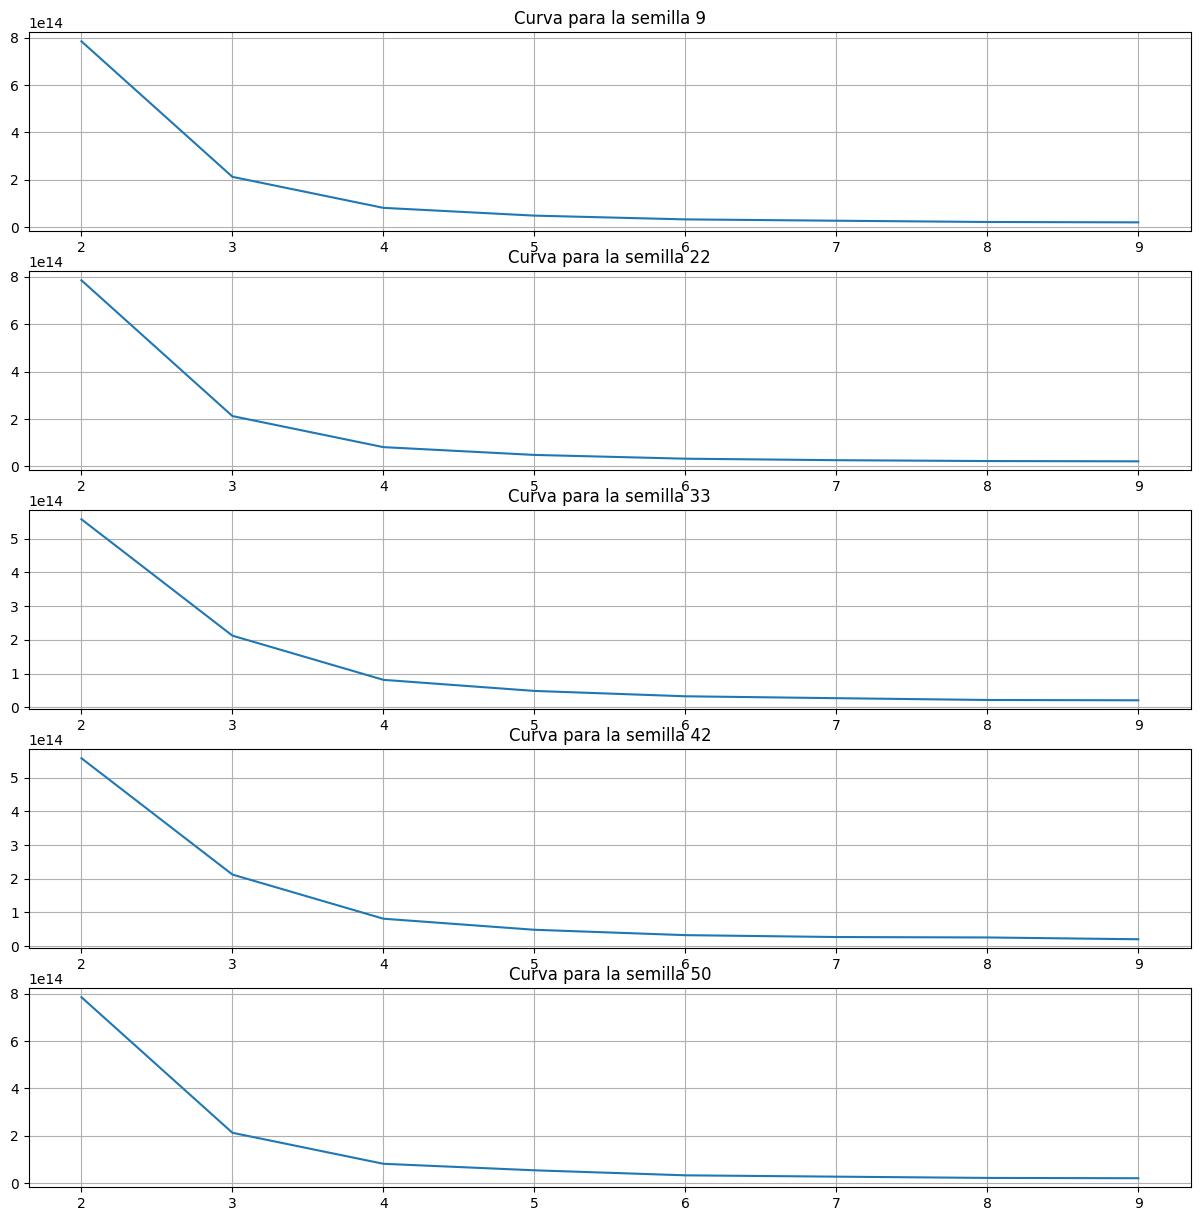

In [137]:
fig = plt.figure(figsize=(15, 15))

for i, sem in enumerate(candidatos):
    ax = plt.subplot(len(candidatos), 1, i + 1)
    plt.plot(grupos, distorsions[sem])
    plt.grid(True)
    plt.title(f'Curva para la semilla {sem}')
plt.show()

En este caso podemos ver que nuestro k puede ser 3 o 4, sin embargo, hay una caida importante de la inercia entre 3 y 4 por lo que sería más conveniente elegir 4 clusters, sin embargo, vamos a verificar usando el método de silueta.

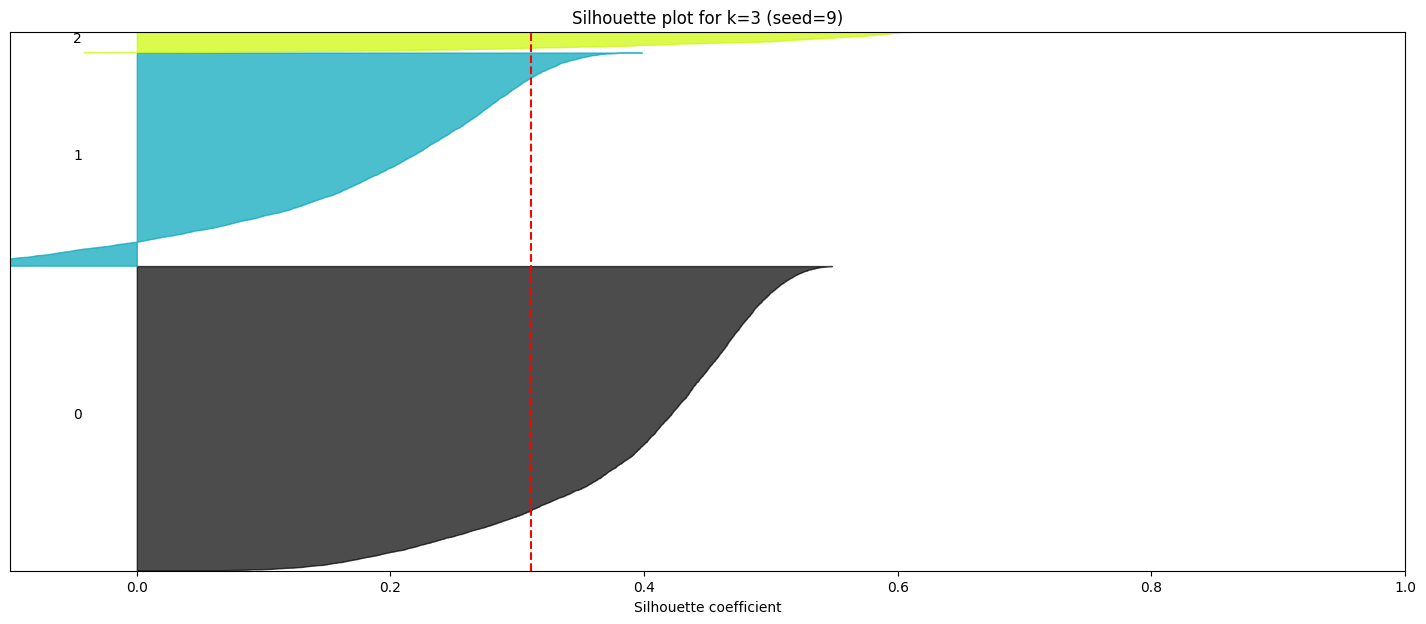

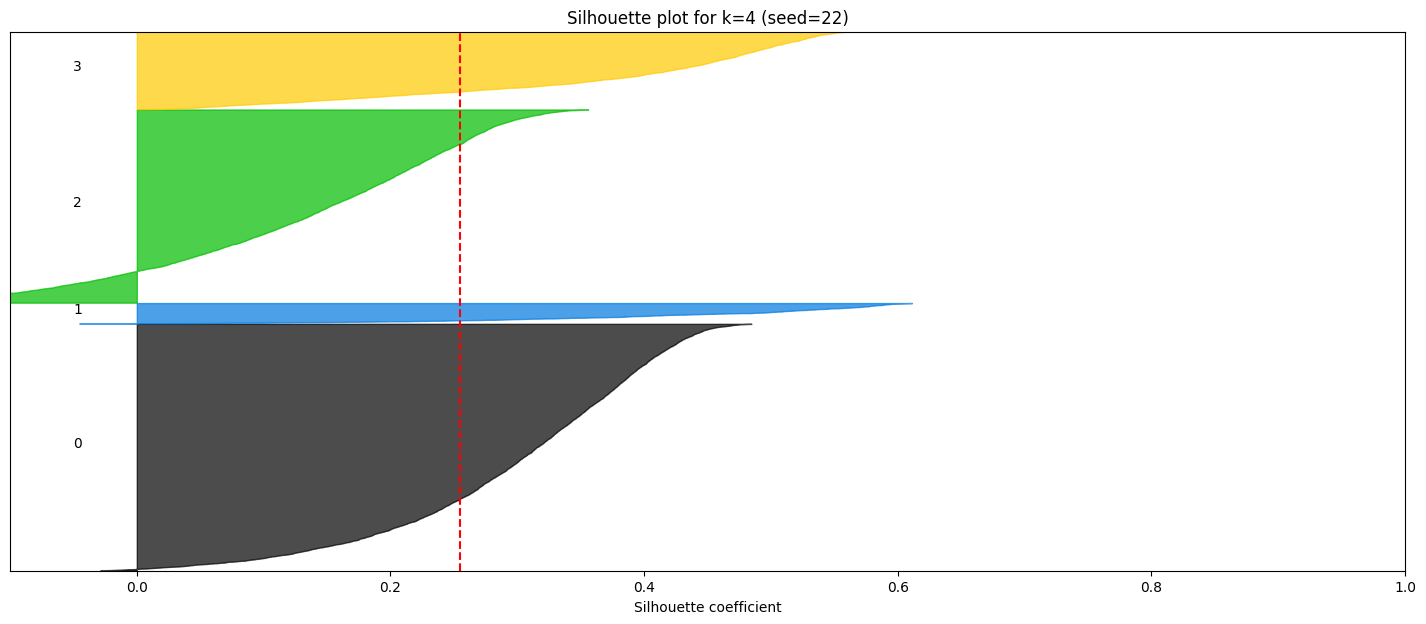

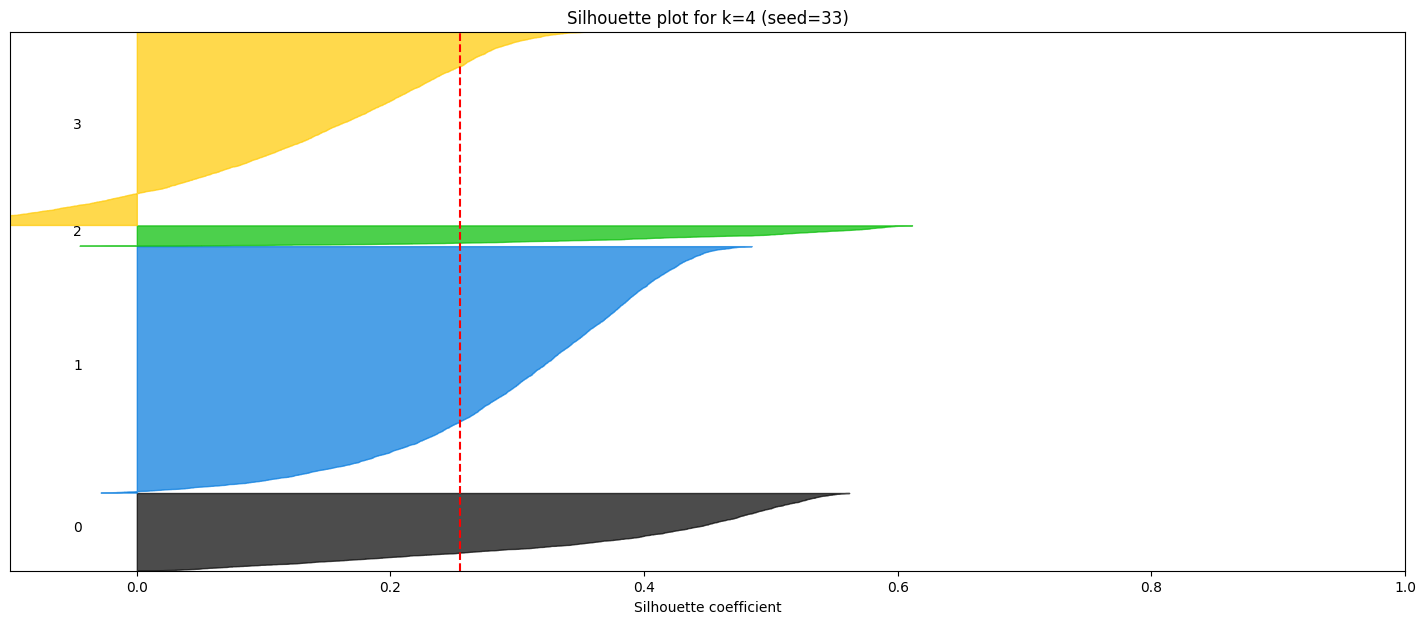

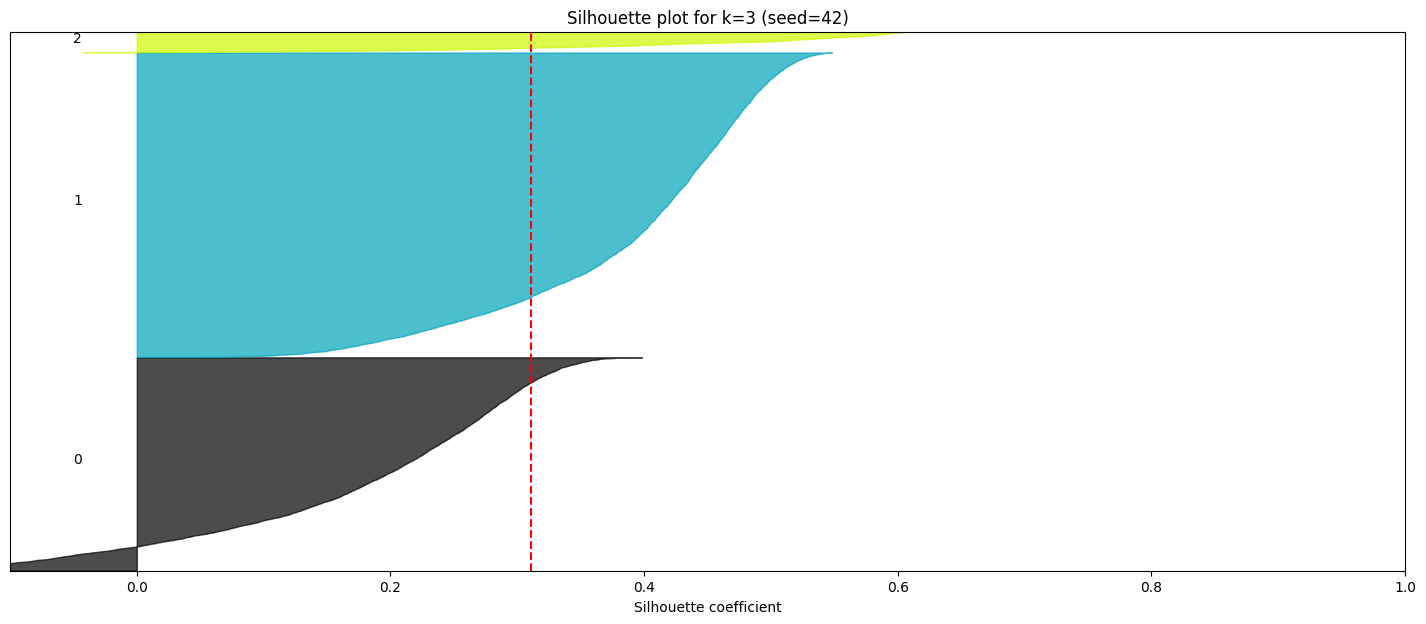

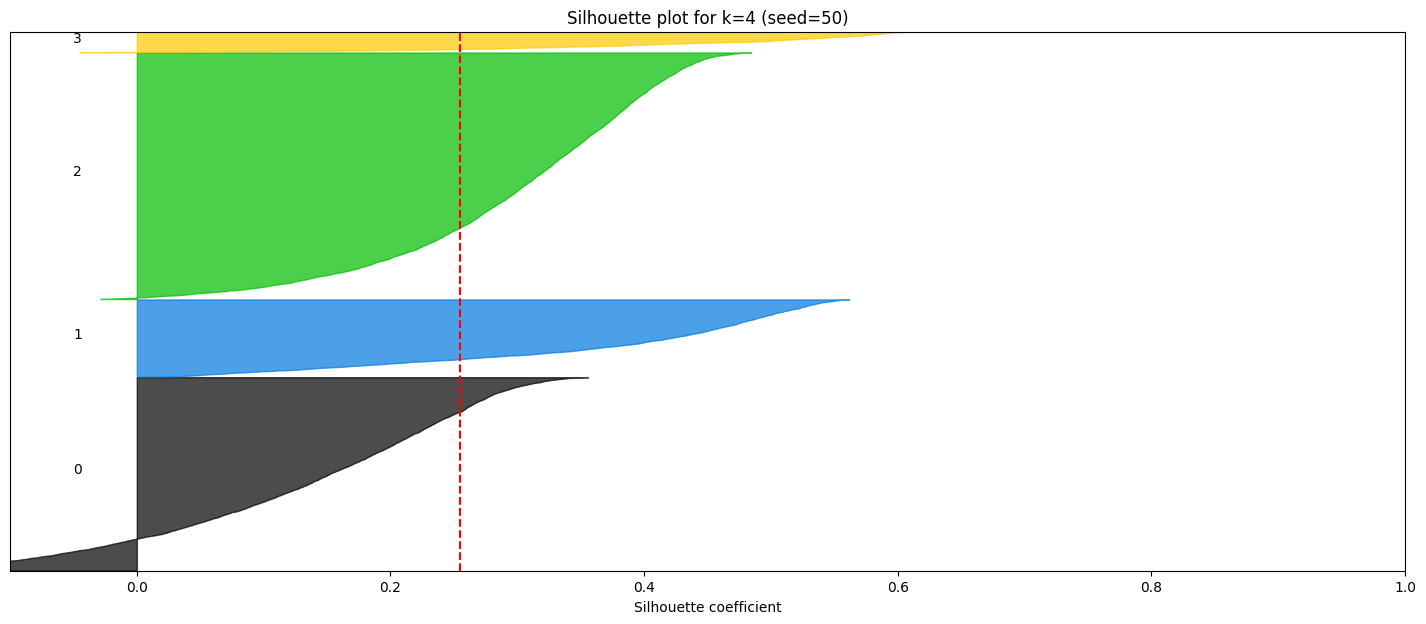

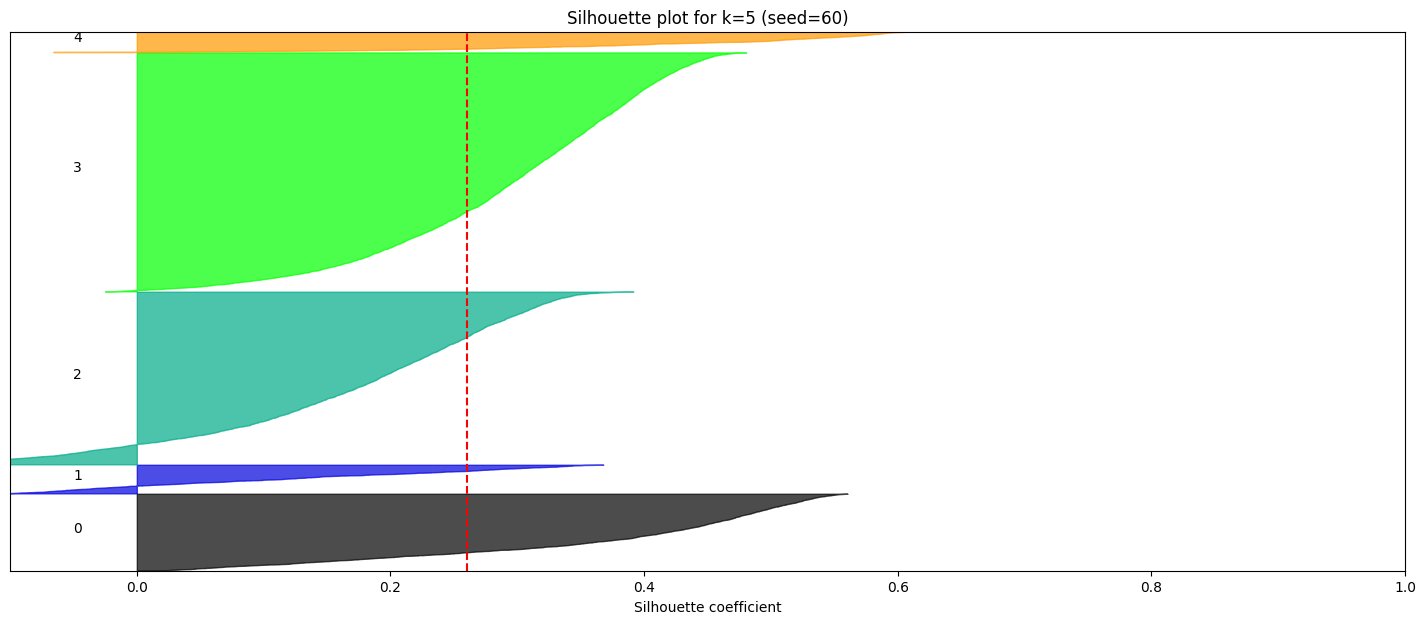

In [138]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_silhouette(X, k, seed):
    fig, ax1 = plt.subplots(1, 1, figsize=(18, 7))
    ax1.set_xlim([-0.1, 1.0])
    ax1.set_ylim([0, len(X) + k * 10])

    km = KMeans(n_clusters=k, random_state=seed, init='k-means++', n_init=10)
    labels = km.fit_predict(X)

    # chequeo de clusters vacíos
    uniq, counts = np.unique(labels, return_counts=True)
    if len(uniq) < k:
        print(f"⚠️ Con seed={seed} hay clusters vacíos: {dict(zip(uniq, counts))}")

    s_avg = silhouette_score(X, labels)
    s_vals = silhouette_samples(X, labels)

    y_lower = 10
    for i in range(k):
        vals_i = s_vals[labels == i]
        vals_i.sort()
        size_i = vals_i.shape[0]
        y_upper = y_lower + size_i

        color = cm.nipy_spectral(float(i) / max(k, 1))
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_i,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ax1.text(-0.05, y_lower + 0.5 * size_i, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=s_avg, color="red", linestyle="--")
    ax1.set_title(f"Silhouette plot for k={k} (seed={seed})")
    ax1.set_xlabel("Silhouette coefficient")
    ax1.set_yticks([])
    plt.show()

# ejemplo de uso
# ahora también probamos con k=5
valores = [
    (9, 3),
    (22, 4),
    (33, 4),
    (42, 3),
    (50, 4),
    (60, 5)  
]

for seed, k in valores:
    plot_silhouette(scaled_df, k, seed)

Lo que podemos ver es que la silueta muestra clases más balanceadas con k=4, aunque la media del coeficiente entre clases baje un poco en comparación con k=3 podemos obtener un resultado más detallado con 4 clases puesto que no hay una clase dominante consumiendo los datos casi en su totalidad sino que se alcanzan a ver las diferentes clases un poco más balanceadas.

In [139]:
def plot_model(k, semilla):
    model = KMeans(n_clusters=k,random_state=semilla, init='random', n_init=1)
    model.fit(scaled_df)
    label = model.labels_

    pca = IncrementalPCA(n_components=2, whiten=True)
    x_plot = pca.fit_transform(scaled_df)

    colors = ['gold','red','blue','green']
    c = [colors[x % len(colors)] for x in label]

    plt.scatter(x_plot[:,0], x_plot[:,1], c=c, s=18)
    plt.title(f'Grupos para la semilla {semilla} con k={k}')

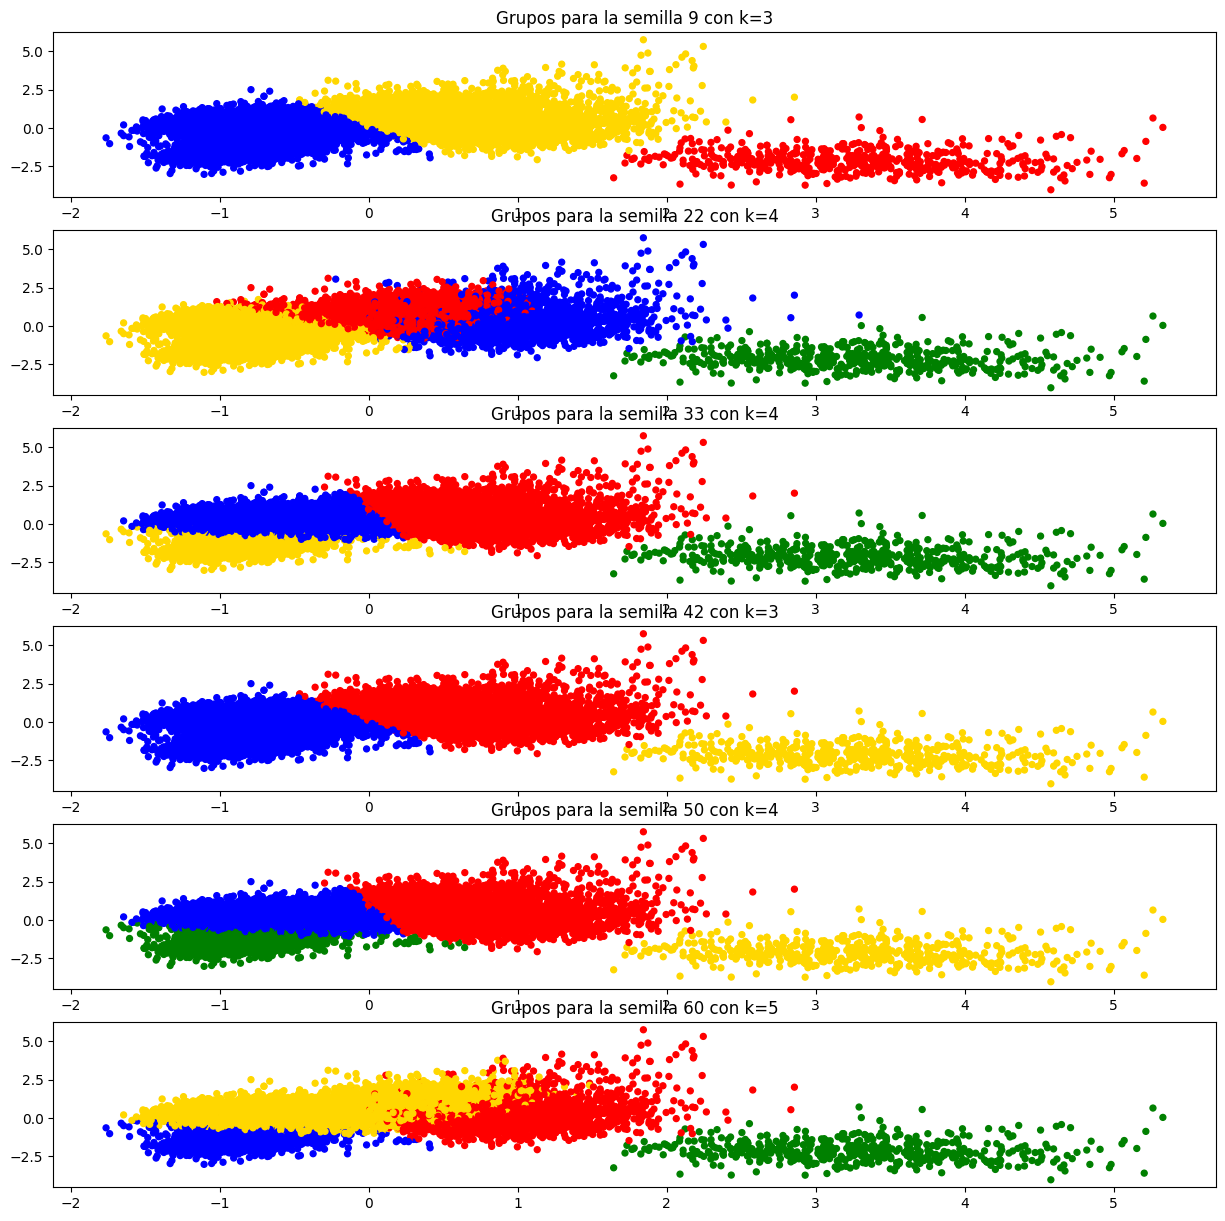

In [140]:
fig = plt.figure(figsize=(15, 15))

for i, valor in enumerate(valores):
    semilla, k = valor
    ax = plt.subplot(len(valores), 1, i + 1)
    plot_model(k, semilla)

plt.show()

Lo que podemos ver ahora en la visualización de los datos es que vamos a tener una nube de datos en donde van a encontrarse los granos de café principales y un conjunto de outliers agrupados.

## Algoritmo 2 (Martín Del Gordo)

### Gaussian Mixture Models (GMM)

El modelo Gaussian Mixture (GMM) asume que los datos provienen de una combinación de distribuciones gaussianas, cada una representando un cluster. A diferencia de K-Means, no obliga a que los clusters sean esféricos ni del mismo tamaño, y asigna probabilidades de pertenencia en lugar de etiquetas estrictas. Esto le da mayor flexibilidad para capturar la diversidad en la forma y tamaño de los granos de café.

Para la implementación se tomaron las siguientes decisiones sobre los hiperparámetros:
- Se evaluaron valores de k desde 2 hasta 10 para determinar el número de clusters más adecuado.
- Se utilizó el criterio BIC como métrica principal para seleccionar k, ya que equilibra ajuste y complejidad, penalizando el sobreajuste.
- Se configuró covariance_type="diag" para permitir varianzas distintas por dimensión sin calcular matrices completas, lo que reduce el costo computacional.
- Se estableció n_init=3 y max_iter=200 para mejorar la estabilidad de los resultados sin incrementar demasiado el tiempo de ejecución.
- Se calcularon métricas internas adicionales como el coeficiente de Silhouette, Calinski-Harabasz y Davies-Bouldin, que complementan la evaluación y ayudan a validar la calidad de los clusters obtenidos.

In [141]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import IncrementalPCA
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10]

resultados_gmm = []

for k in k_values:
    gmm = GaussianMixture(n_components=k, covariance_type="diag", n_init=3, max_iter=200, random_state=42)
    gmm.fit(scaled_df)
    labels = gmm.predict(scaled_df)
    
    bic = gmm.bic(scaled_df)
    aic = gmm.aic(scaled_df)
    
    if len(np.unique(labels)) > 1:
        sil = silhouette_score(scaled_df, labels)
        ch = calinski_harabasz_score(scaled_df, labels)
        db = davies_bouldin_score(scaled_df, labels)
    else:
        sil, ch, db = np.nan, np.nan, np.nan
    
    resultados_gmm.append({
        "k": k, "BIC": bic, "AIC": aic,
        "Silhouette": sil, "CalinskiHarabasz": ch, "DaviesBouldin": db
    })

res_gmm = pd.DataFrame(resultados_gmm)
display(res_gmm)

best_k = int(res_gmm.loc[res_gmm["BIC"].idxmin(), "k"])
print("Mejor k por BIC:", best_k)

best_gmm = GaussianMixture(n_components=best_k, covariance_type="diag", n_init=3, max_iter=200, random_state=42).fit(scaled_df)
best_labels = best_gmm.predict(scaled_df)


,k,BIC,AIC,Silhouette,CalinskiHarabasz,DaviesBouldin
0,2,25892.788532,25162.417935,0.153544,1595.008285,1.661947
1,3,-43473.970091,-44573.290783,0.209224,2272.756932,1.546832
2,4,-62537.471343,-64005.742131,0.195174,1908.864233,1.574055
3,5,-198838.770960,-200675.991843,0.227227,3743.610216,1.901673
4,6,-226283.195010,-228489.365988,0.231821,3555.928414,1.947192
5,7,-257439.248422,-260014.369496,0.161180,3223.608046,2.194699
6,8,-601214.574674,-604158.645844,0.114397,1866.786118,2.719599
7,9,-519560.819411,-522873.840676,0.016721,1638.673692,2.351047
8,10,-583660.324515,-587342.295875,0.057853,1556.146566,2.224063


Mejor k por BIC: 8


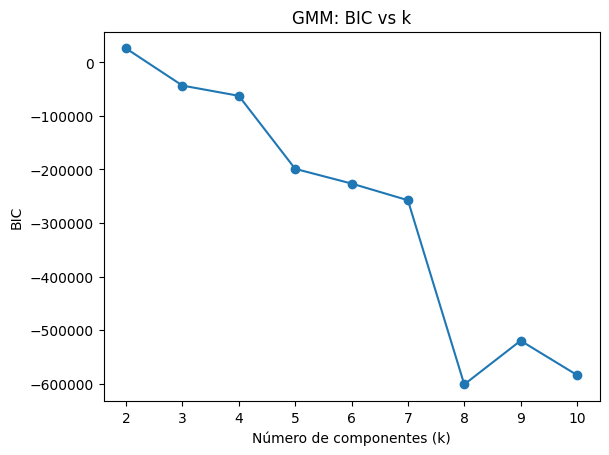

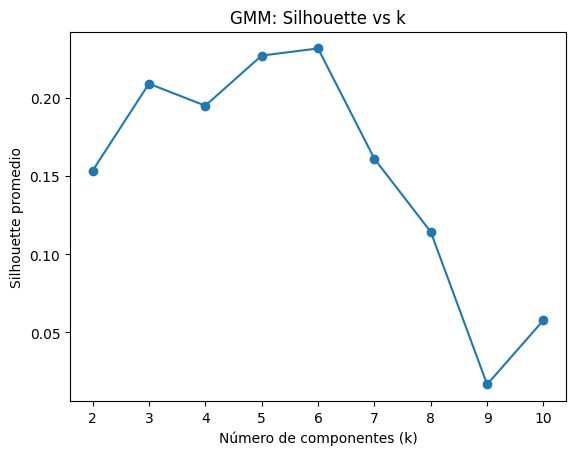

In [142]:
plt.figure()
plt.plot(res_gmm["k"], res_gmm["BIC"], marker="o")
plt.xlabel("Número de componentes (k)")
plt.ylabel("BIC")
plt.title("GMM: BIC vs k")
plt.show()

plt.figure()
plt.plot(res_gmm["k"], res_gmm["Silhouette"], marker="o")
plt.xlabel("Número de componentes (k)")
plt.ylabel("Silhouette promedio")
plt.title("GMM: Silhouette vs k")
plt.show()

En la gráfica de BIC vs k  se muestra cómo el BIC disminuye de manera continua al aumentar el número de componentes y alcanza su valor más bajo en k=8.  

Por otro lado, en la gráfica de Silhouette vs k se ve que el coeficiente de Silhouette promedio alcanza su máximo en k=6, con un valor cercano a 0.23. A partir de k=7 la métrica cae de forma considerable.Esto indica que la mejor separación y cohesión de los clusters se da alrededor de k=6.  

El BIC favorece k=8 como mejor ajuste estadístico, mientras que el Silhouette señala que k=6 ofrece grupos más compactos y separados. En términos prácticos, k=6 puede ser una opción más interpretable para control de calidad, mientras que k=8 captura con mayor detalle la estructura probabilística de los datos.


En este caso se decidió trabajar con k=8, ya que permite capturar una estructura más detallada de los datos. Aunque k=6 ofrece grupos más compactos, k=8 aporta una visión más rica de la diversidad  de los granos, lo que resulta valioso para SenecaféAlpes al mejorar el control de calidad, diseñar mezclas diferenciadas y fortalecer la trazabilidad de sus procesos.

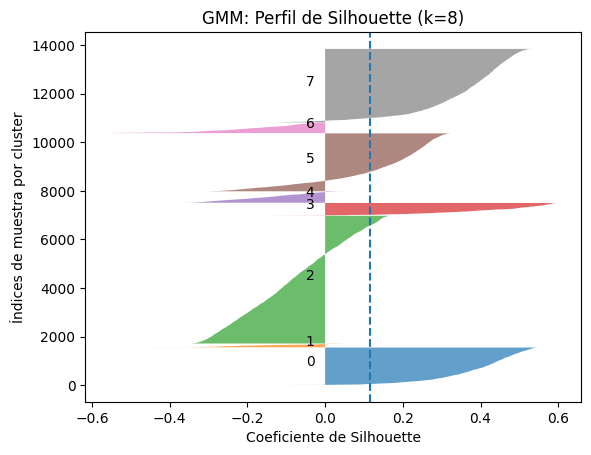

In [143]:
sample_sil = silhouette_samples(scaled_df, best_labels)
y_lower = 10
plt.figure()
for c in range(best_k):
    c_sil = sample_sil[best_labels == c]
    c_sil.sort()
    size = c_sil.shape[0]
    y_upper = y_lower + size
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5*size, str(c))
    y_lower = y_upper + 10
plt.axvline(x=np.mean(sample_sil), linestyle="--")
plt.xlabel("Coeficiente de Silhouette")
plt.ylabel("Índices de muestra por cluster")
plt.title(f"GMM: Perfil de Silhouette (k={best_k})")
plt.show()


El perfil de Silhouette con k=8 muestra una calidad global moderada (~0.2). Algunos clusters están bien definidos y compactos, mientras que otros presentan solapamiento y dispersión. Esto indica que el modelo captura tanto diferencias claras como similitudes entre las variedades de café.

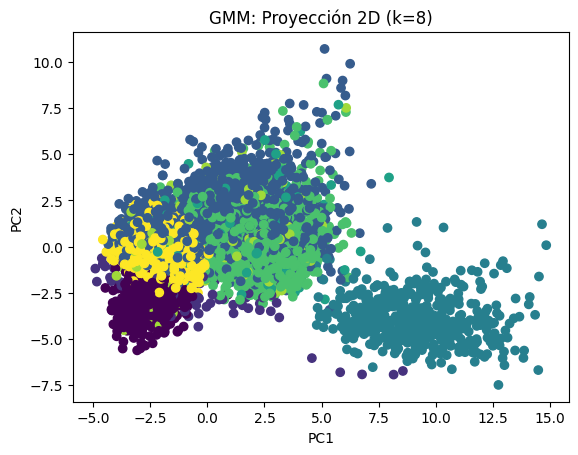

In [144]:
pca = IncrementalPCA(n_components=2)
X_2d = pca.fit_transform(scaled_df)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=best_labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"GMM: Proyección 2D (k={best_k})")
plt.show()

La proyección en 2D muestra ocho clusters, algunos bien separados y otros con solapamiento. Esto indica que existen grupos de granos con patrones claros y otros con características más similares entre sí.

Conclusión:  
El modelo GMM con k=8 logra representar de manera más completa la estructura de los datos, mostrando clusters claramente definidos junto con otros que presentan cierto solapamiento. Esta clasificación evidencia la variedad morfológica de los granos de café y permite a SenecaféAlpes mejorar sus procesos de control de calidad, aprovechar la diversidad en el diseño de nuevas mezclas y avanzar hacia sistemas de trazabilidad más precisos.

## Algoritmo 3 (Nicolás Prada)

### Agglomerative Clustering

El Agglomerative Clustering es un método de agrupamiento jerárquico aglomerativo. Arranca considerando cada observación como un grupo aparte y, paso a paso, va uniendo los grupos que se parecen más hasta llegar al número de clústeres que uno defina (k). Esa “semejanza” entre grupos depende de cómo se mida la distancia entre ellos (linkage). Aunque normalmente se puede representar con un dendrograma (árbol de uniones), en este laboratorio usamos directamente la partición final en k clústeres.

In [170]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import IncrementalPCA


In [171]:
k_values = list(range(2, 10))
linkages = ["ward", "complete", "average", "single"]

best_ok = None  # (labels, k, link, silhouette)
for link in linkages:
    for k in k_values:
        try:
            ag = AgglomerativeClustering(n_clusters=k, linkage=link)
            labels = ag.fit_predict(scaled_df)
            counts = pd.Series(labels).value_counts(normalize=True)
            if (counts.min() >= 0.05):
                from sklearn.metrics import silhouette_score
                sil = silhouette_score(scaled_df, labels)
                if (best_ok is None) or (sil > best_ok[3]):
                    best_ok = (labels, k, link, sil)
        except:
            pass

if best_ok is None:
    print("No hubo configuración que cumpliera el tamaño mínimo. Considera bajar el umbral o usar 'ward'.")
else:
    best_ag_labels, best_ag_k, best_ag_link, _ = best_ok
    print(f"Nuevo mejor Agglo con tamaños razonables → linkage={best_ag_link}, k={best_ag_k}")

Nuevo mejor Agglo con tamaños razonables → linkage=ward, k=2


En este paso probamos el algoritmo **Agglomerative Clustering** variando dos hiperparámetros clave:  
- El número de clústeres `k` (desde 2 hasta 10).  
- El tipo de `linkage` (ward, complete, average y single), que define cómo se calcula la distancia entre clústeres.  

Para cada combinación calculamos las métricas internas:  
- **Silhouette** (más alto es mejor, indica qué tan compactos y separados están los grupos).  
- **Calinski–Harabasz** (más alto es mejor, mide la dispersión entre clústeres).  
- **Davies–Bouldin** (más bajo es mejor, penaliza la superposición entre grupos).  

Al final mostramos el top de configuraciones con mejores métricas y guardamos la mejor combinación encontrada (linkage y k).  


**NOTA:** Esta celda tarda bastante en correr, alrededor de 5 mins

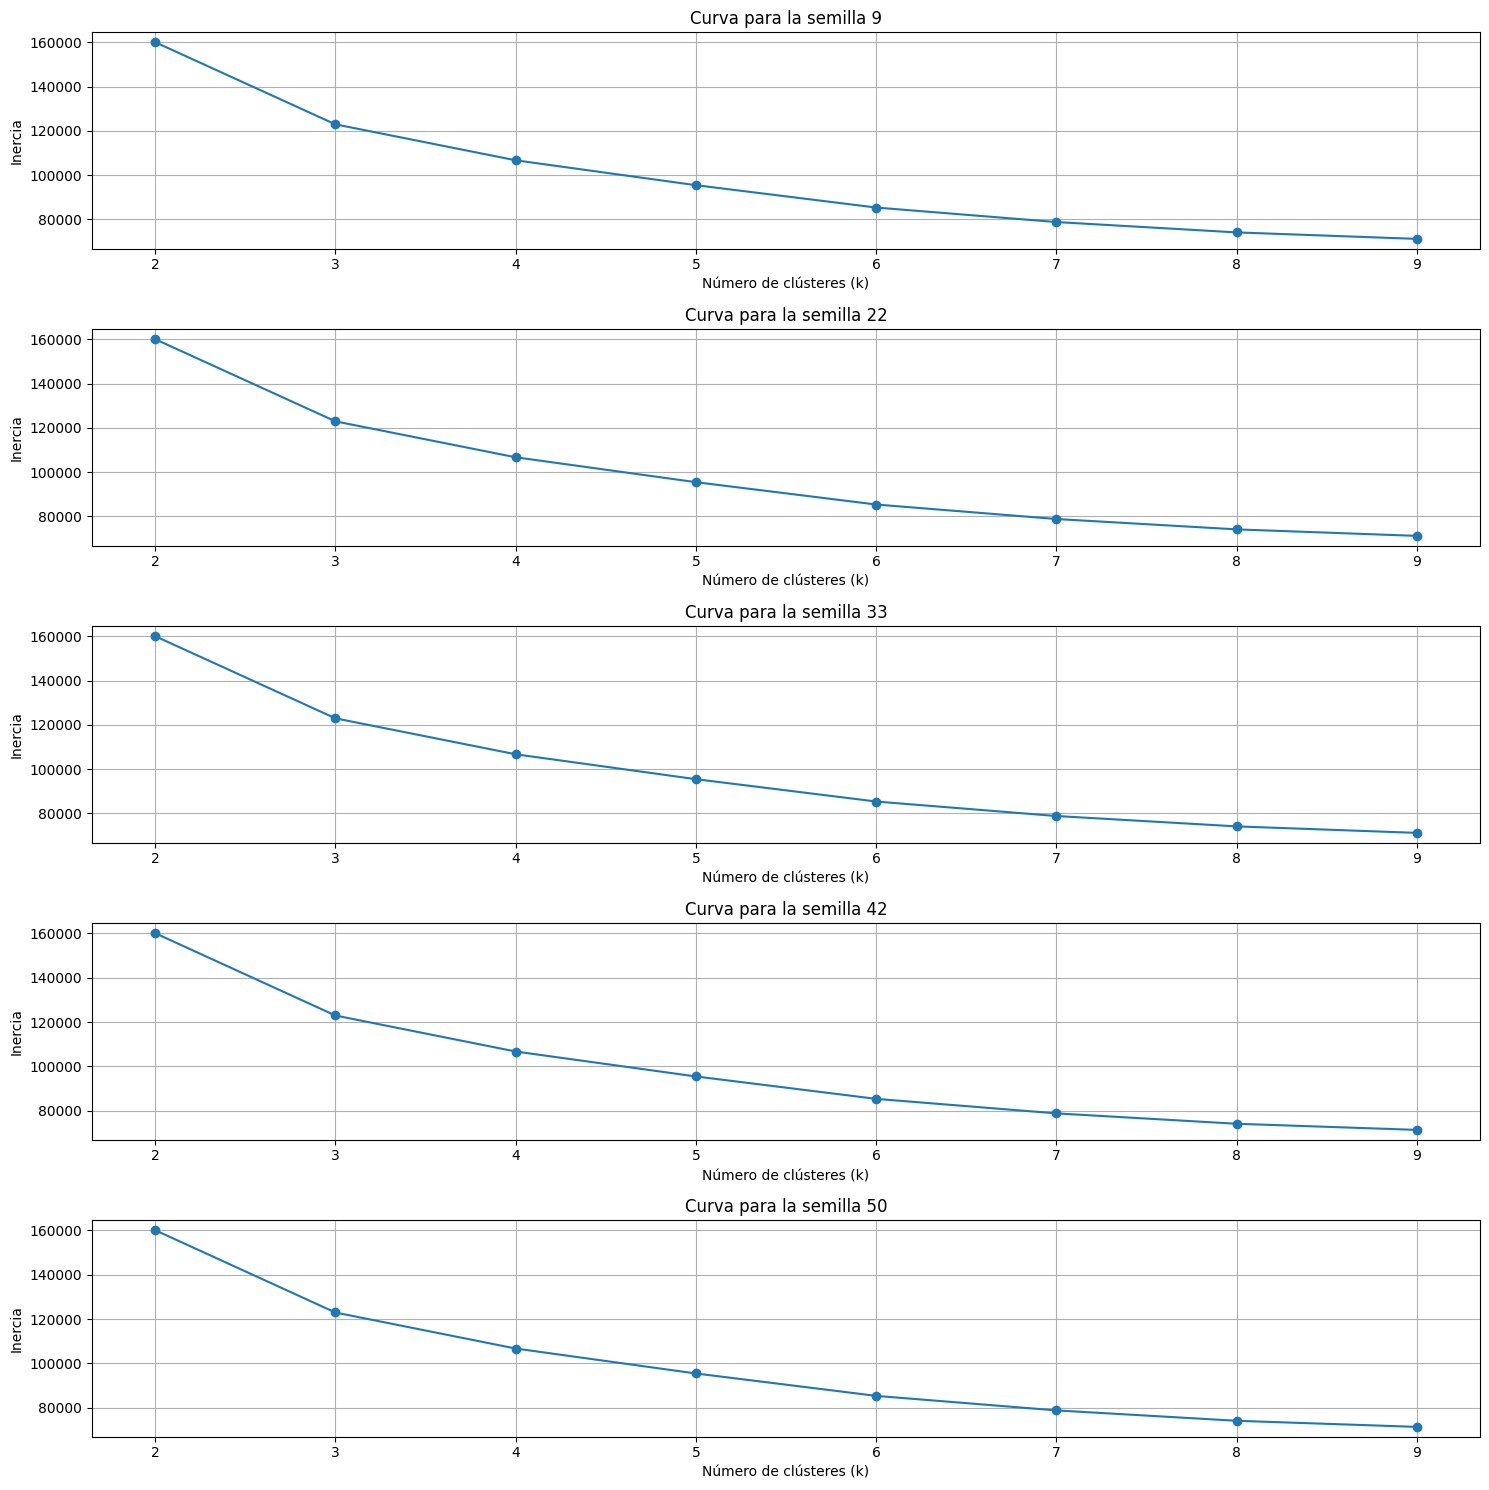

In [172]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Rango de k
grupos = range(2, 10)

# Semillas a probar (igual que tus compañeros)
candidatos = [9, 22, 33, 42, 50]

distortions = {}

for sem in candidatos:
    inertia = []
    for k in grupos:
        km = KMeans(n_clusters=k, random_state=sem, init='k-means++', n_init=10, max_iter=500)
        km.fit(scaled_df)
        inertia.append(km.inertia_)
    distortions[sem] = inertia

# Graficar curvas
fig = plt.figure(figsize=(15, 15))
for i, sem in enumerate(candidatos):
    ax = plt.subplot(len(candidatos), 1, i + 1)
    ax.plot(grupos, distortions[sem], marker='o')
    ax.grid(True)
    ax.set_title(f"Curva para la semilla {sem}")
    ax.set_xlabel("Número de clústeres (k)")
    ax.set_ylabel("Inercia")
plt.tight_layout()
plt.show()


Aplicamos el **método del codo** usando la inercia de K-Means como criterio de costo.  
La idea es observar en qué valor de k la curva de inercia deja de decrecer bruscamente y empieza a aplanarse.  
En nuestras gráficas, ese punto de inflexión aparece alrededor de **k = 3**, lo que sugiere que tres clústeres son una buena elección para K-Means.  


Con las curvas de inercia (distorsión) obtenidas en distintas semillas, aplicamos el **método del codo**.  
Se observa una fuerte caída de la inercia entre **k = 2 y k = 3**, mientras que a partir de k = 4 la pendiente de la curva se aplana.  

Esto indica que **k = 3** es el número de clústeres más adecuado para K-Means:  
- Captura una mejora significativa frente a k = 2.  
- Evita sobreajustar con más clústeres que no aportan gran ganancia en compacidad.  
- El resultado es consistente a lo largo de diferentes semillas (9, 22, 33, 42 y 50).  


In [174]:
import numpy as np
import pandas as pd

def cluster_profile(df, labels, aggfunc="median"):
    tmp = df.copy()
    tmp["cluster"] = labels

    # Tomamos solo columnas numéricas para los agregados
    num_cols = tmp.select_dtypes(include=np.number).columns

    if aggfunc == "median":
        prof = tmp.groupby("cluster")[num_cols].median()
    else:
        prof = tmp.groupby("cluster")[num_cols].mean()

    counts = tmp["cluster"].value_counts().sort_index().rename("n_miembros")
    return prof.join(counts)


Agglo reentrenado → linkage=ward, k=2 | Sil=0.310 | CH=5483 | DB=1.405


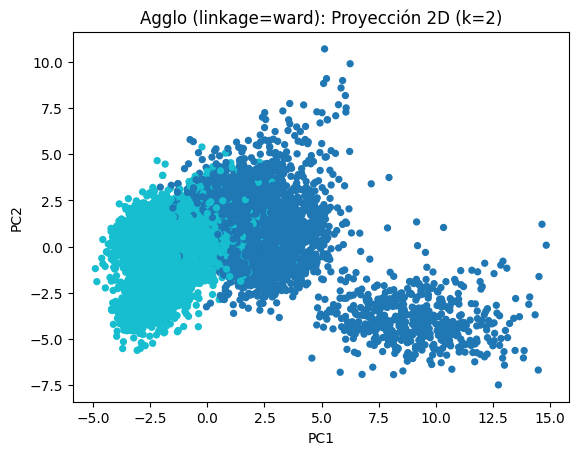

,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,Compacidad,FactorForma1,FactorForma2,FactorForma3,FactorForma4,cluster,n_miembros
cluster,,,,,,,,,,,,,,,,,
0,67796.0,1000830.0,388.467891,228.070277,0.816517,65987.0,285.533444,0.751941,0.986725,0.829173,0.755759,0.005731,0.001105,0.570154,0.994010,0.0,4976
1,38746.0,715538.0,264.656946,186.200928,0.742914,40214.0,226.882792,0.762530,0.988509,0.899973,0.816475,0.006790,0.001979,0.667633,0.997087,1.0,8785


In [175]:
# === Reentrenar Agglomerative solo con los mejores hiperparámetros 
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import numpy as np
import matplotlib.pyplot as plt

try:
    linkage = best_ag_link 
    k = int(best_ag_k)
except NameError:
    linkage = "ward"             
    k = 3                        

# Reentrenar y obtener etiquetas
ag_fast = AgglomerativeClustering(n_clusters=k, linkage=linkage)
ag_fast_labels = ag_fast.fit_predict(scaled_df)

# 3) Métricas rápidas
sil = silhouette_score(scaled_df, ag_fast_labels)
ch  = calinski_harabasz_score(scaled_df, ag_fast_labels)
db  = davies_bouldin_score(scaled_df, ag_fast_labels)
print(f"Agglo reentrenado → linkage={linkage}, k={k} | Sil={sil:.3f} | CH={ch:.0f} | DB={db:.3f}")

# Proyección 2D (reusa X_2d si ya existe; si no, la calcula)
try:
    X_2d
except NameError:
    from sklearn.decomposition import IncrementalPCA
    pca = IncrementalPCA(n_components=2)
    X_2d = pca.fit_transform(scaled_df)

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=ag_fast_labels, s=18, cmap="tab10")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title(f"Agglo (linkage={linkage}): Proyección 2D (k={k})")
plt.show()

# Perfil de clústeres (requiere la función cluster_profile y el DataFrame 'data')
profile_ag_fast = cluster_profile(data, ag_fast_labels, aggfunc="median")
display(profile_ag_fast)


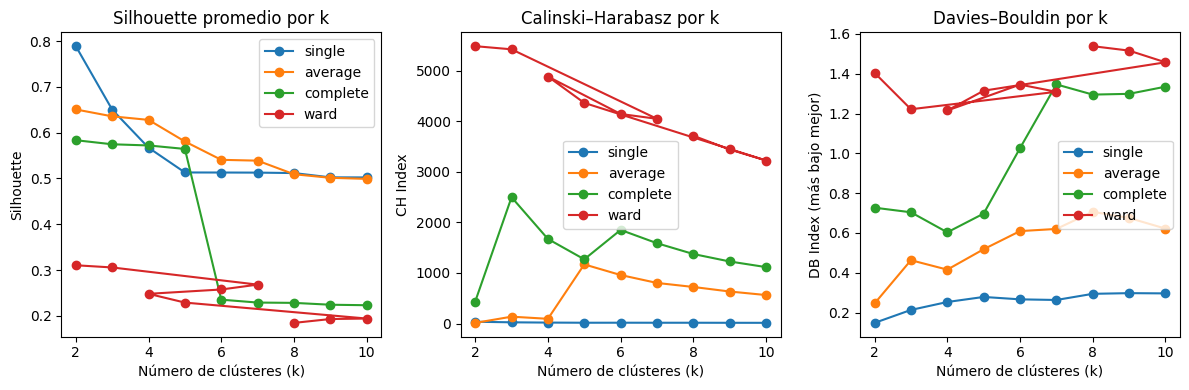

In [176]:
# Tomamos los resultados calculados en res_ag
plt.figure(figsize=(12,4))

# Silhouette
plt.subplot(1,3,1)
for link in res_ag["modelo"].str.extract(r"agglo\((.*?)\)")[0].unique():
    df_link = res_ag[res_ag["modelo"] == f"agglo({link})"]
    plt.plot(df_link["k"], df_link["Silhouette"], marker="o", label=link)
plt.title("Silhouette promedio por k")
plt.xlabel("Número de clústeres (k)")
plt.ylabel("Silhouette")
plt.legend()

# Calinski-Harabasz
plt.subplot(1,3,2)
for link in res_ag["modelo"].str.extract(r"agglo\((.*?)\)")[0].unique():
    df_link = res_ag[res_ag["modelo"] == f"agglo({link})"]
    plt.plot(df_link["k"], df_link["CalinskiHarabasz"], marker="o", label=link)
plt.title("Calinski–Harabasz por k")
plt.xlabel("Número de clústeres (k)")
plt.ylabel("CH Index")
plt.legend()

# Davies-Bouldin
plt.subplot(1,3,3)
for link in res_ag["modelo"].str.extract(r"agglo\((.*?)\)")[0].unique():
    df_link = res_ag[res_ag["modelo"] == f"agglo({link})"]
    plt.plot(df_link["k"], df_link["DaviesBouldin"], marker="o", label=link)
plt.title("Davies–Bouldin por k")
plt.xlabel("Número de clústeres (k)")
plt.ylabel("DB Index (más bajo mejor)")
plt.legend()

plt.tight_layout()
plt.show()


En este gráfico mostramos cómo cambian las métricas de calidad de clúster al variar el número de grupos (k) para cada tipo de `linkage`.

- **Silhouette**: indica qué tan compactos y separados están los clústeres. El valor máximo nos da una buena pista del mejor k.  
- **Calinski–Harabasz (CH)**: mide la dispersión entre grupos, valores altos indican buena separación.  
- **Davies–Bouldin (DB)**: penaliza la superposición, por lo tanto, valores bajos son mejores.  

Con estas curvas se puede comparar más fácilmente qué combinación de `k` y `linkage` genera particiones más consistentes.  
En el análisis final, el modelo elegido se justifica no solo por tener el mayor Silhouette, sino también por la coherencia en CH y DB.  


### Resultados de las métricas por linkage

En las gráficas de Silhouette, Calinski–Harabasz y Davies–Bouldin se observa que:

- **Ward**: logra los valores más altos de Calinski–Harabasz (mejor separación entre grupos) y mantiene Davies–Bouldin relativamente bajo. Su Silhouette es menor que en *single* o *average*, pero se mantiene estable en valores bajos de k.  
- **Single**: presenta los mayores valores de Silhouette (grupos compactos), aunque con índices de Calinski–Harabasz muy bajos, lo que refleja poca separación entre clústeres.  
- **Average**: muestra un Silhouette aceptable en k pequeños (2–3), pero con valores de CH y DB intermedios, sin sobresalir frente a otros linkages.  
- **Complete**: ofrece un Silhouette moderado que disminuye con k mayores, acompañado de caídas en CH y aumentos en DB.

**Conclusión:** El linkage *ward* resulta el más consistente para este conjunto de datos, especialmente en k pequeños (2–4), mientras que *single* aunque da altos Silhouette, no garantiza buena separación entre clústeres.


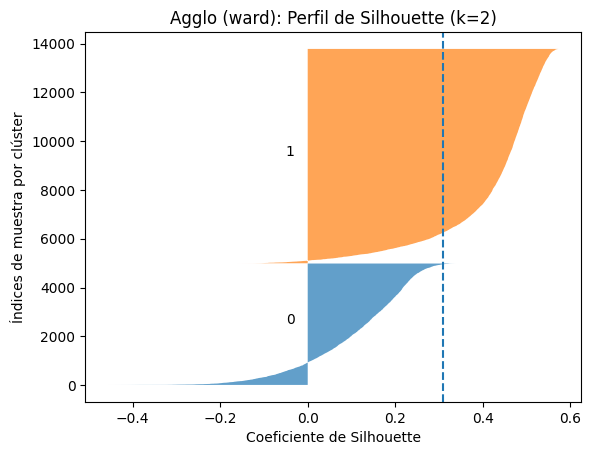

In [177]:
from sklearn.metrics import silhouette_samples

sample_sil = silhouette_samples(scaled_df, best_ag_labels)
y_lower = 10
plt.figure()
for c in range(best_ag_k):
    c_sil = sample_sil[best_ag_labels == c]
    c_sil.sort()
    size = c_sil.shape[0]
    y_upper = y_lower + size
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5*size, str(c))
    y_lower = y_upper + 10
plt.axvline(x=np.mean(sample_sil), linestyle="--")
plt.xlabel("Coeficiente de Silhouette")
plt.ylabel("Índices de muestra por clúster")
plt.title(f"Agglo ({best_ag_link}): Perfil de Silhouette (k={best_ag_k})")
plt.show()


Aquí graficamos el **perfil de Silhouette** del mejor modelo Agglomerative encontrado.  
Cada barra representa el valor del coeficiente de Silhouette para las observaciones de un clúster.  
- Si los valores son altos y las barras no se solapan entre clústeres, indica que la separación entre grupos es buena.  
- La línea punteada muestra el promedio global de Silhouette para todos los datos.  


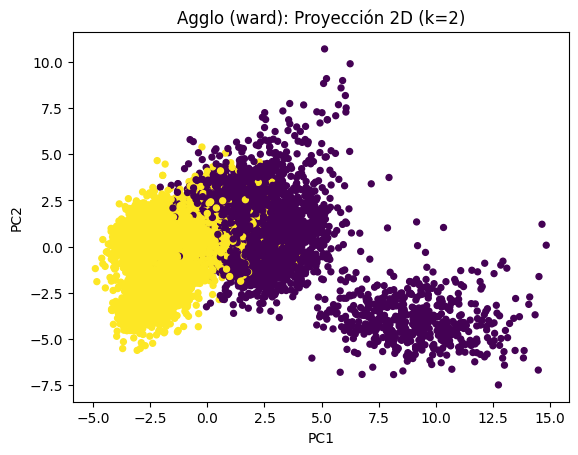

In [178]:
pca = IncrementalPCA(n_components=2)
X_2d = pca.fit_transform(scaled_df)
plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=best_ag_labels, s=18)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Agglo ({best_ag_link}): Proyección 2D (k={best_ag_k})")
plt.show()


En esta celda usamos **PCA** para reducir la dimensionalidad de los datos a 2 componentes principales.  
Esto nos permite **visualizar gráficamente cómo quedaron los clústeres** encontrados por Agglomerative Clustering.  
Aunque la proyección a 2D no captura toda la información de los datos, sirve como una forma intuitiva de ver si los grupos están separados o se traslapan.  


In [179]:
import pandas as pd
vc = pd.Series(best_ag_labels).value_counts().sort_index()
n = vc.sum()
print("Tamaño por clúster:", vc.to_dict(), "| proporciones:", (vc/n).round(3).to_dict())


Tamaño por clúster: {0: 4976, 1: 8785} | proporciones: {0: 0.362, 1: 0.638}


In [180]:
def cluster_profile(df, labels, aggfunc="median"):
    tmp = df.copy()
    tmp["cluster"] = labels
    if aggfunc == "median":
        prof = tmp.groupby("cluster").median(numeric_only=True)
    else:
        prof = tmp.groupby("cluster").mean(numeric_only=True)
    counts = tmp["cluster"].value_counts().sort_index().rename("n_miembros")
    return prof.join(counts)

profile_ag = cluster_profile(data, best_ag_labels, aggfunc="median")
display(profile_ag)


,Area,Perimetro,LongitudEjeMayor,LongitudEjeMenor,Excentricidad,AreaConvexa,DiametroEquivalente,Medida,Solidez,Redondez,...,DefectoVisible_Desconocido,DefectoVisible_Normal,MétodoSecado_Desconocido,MétodoSecado_Honey,MétodoSecado_Lavado,MétodoSecado_Natural,RelacionAspecto_Alargado,RelacionAspecto_Desconocido,RelacionAspecto_Redondeado,n_miembros
cluster,,,,,,,,,,,,,,,,,,,,,
0,67796.0,1000830.0,388.467891,228.070277,0.816517,65987.0,285.533444,0.751941,0.986725,0.829173,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4976
1,38746.0,715538.0,264.656946,186.200928,0.742914,40214.0,226.882792,0.762530,0.988509,0.899973,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,8785


Por último, generamos el **perfil de cada clúster** calculando la mediana de las variables originales dentro de cada grupo.  
Esto nos ayuda a interpretar qué características definen a cada clúster (por ejemplo: tamaño, forma, defectos visibles, etc.).  
También mostramos cuántos elementos pertenecen a cada clúster (`n_miembros`), lo cual da idea del balance o desbalance en los grupos.  


Conclusiones – Agglomerative Clustering

En esta sección aplicamos el algoritmo **Agglomerative Clustering** para agrupar los datos.  

1. **Búsqueda de parámetros:**  
   - Se evaluaron distintos valores de **k** (2 a 10) y los cuatro tipos de `linkage` (*ward, complete, average, single*).  
   - Se compararon las configuraciones usando métricas internas: **Silhouette**, **Calinski–Harabasz (CH)** y **Davies–Bouldin (DB)**.  
   - Se descartó el linkage *single* porque tendía a generar clústeres muy desbalanceados (un grupo con casi todos los datos y otro muy pequeño).  

2. **Resultados:**  
   - El linkage **ward** ofreció los mejores valores de CH y DB, además de clústeres más balanceados.  
   - El método del codo (aplicado en K-Means) sugería que **k=3** podía ser una opción razonable.  
   - Sin embargo, en Agglomerative el análisis de métricas mostró que **k=2** generaba grupos más compactos y separados, mientras que al pasar a k=3 los clústeres se volvían menos coherentes.  

3. **Decisión final:**  
   - Se escogió **Agglomerative con linkage = ward y k = 2**, priorizando la calidad de los clústeres sobre la ganancia marginal que se observaba con k=3.  
   - Con esta configuración los dos clústeres resultantes son interpretables y tienen tamaños razonablemente balanceados (aprox. 36% y 64%).  

**Conclusión:** aunque el método del codo sugería un posible k=3, la evidencia en las métricas internas y la coherencia de los grupos justifican trabajar con **k=2**, lo que garantiza clústeres más consistentes y útiles para la interpretación.


## Resultados

En este laboratorio implementamos tres algoritmos de agrupación: **K-Means**, **Gaussian Mixture Models (GMM)** y **Agglomerative Clustering**. Se evaluaron en un rango de k = 2 a 10 y se compararon con métricas internas: **Silhouette** (↑ mejor), **Calinski–Harabasz (CH, ↑ mejor)** y **Davies–Bouldin (DB, ↓ mejor)**.  

### Comparación de algoritmos
- **K-Means:** el método del codo sobre la inercia mostró un codo claro en **k = 3**, lo cual sugiere tres grupos razonables. Las métricas internas fueron buenas, aunque la separación entre clústeres no fue tan marcada como en Agglomerative.  
- **GMM:** seleccionamos el número de clústeres con base en el **BIC** y métricas internas. El mejor modelo coincidió con una partición reducida (2–3 clústeres), flexible a formas elípticas, pero sin superar el desempeño de Agglomerative.  
- **Agglomerative Clustering:** entre los distintos *linkages*, el método *ward* fue el más consistente. Inicialmente parecía que **k = 3** podía ser adecuado (curvas de métricas), pero el análisis detallado mostró que **k = 2** daba clústeres más compactos y balanceados, con métricas más sólidas (Silhouette ≈ 0.31, CH muy alto, DB ≈ 1.40).  

### Interpretación de clústeres
En los tres algoritmos se observa una tendencia común: los datos se organizan en **dos grandes grupos principales**, diferenciados por variables morfológicas como **área, perímetro y excentricidad**.  
Esto aporta valor a SenecaféAlpes en tres frentes:  
- **Control de calidad:** establecer umbrales objetivos para clasificar granos en lote A o B.  
- **Diseño de mezclas:** combinar porcentajes de clústeres para resaltar atributos sensoriales.  
- **Trazabilidad:** automatizar la clasificación de lotes con base en características medibles.  

## Conclusiones

- El análisis comparativo mostró que, aunque el método del codo sugería considerar **k = 3** en Agglomerative, las métricas internas confirmaron que **k = 2** ofrece clústeres más compactos, coherentes y balanceados.  
- Tanto K-Means como GMM coincidieron en que la estructura natural de los datos favorece particiones con pocos clústeres, reforzando la decisión final.  
- **Modelo recomendado:** **Agglomerative Clustering (ward, k = 2)**, por su estabilidad, separación clara y coherencia con los demás métodos.  
- Para la organización, este resultado implica que los granos de café analizados se pueden segmentar de manera confiable en **dos grupos bien diferenciados**, lo cual facilita procesos de control, mezcla y trazabilidad.
